In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

from bio_network.engine.neurons import IzhikevichPopulation
from bio_network.engine.scheduler import simulate
from bio_network.engine.synapses_sparse import SparseSynapses
from bio_network.senses import InputProjection, LabelsReadout, Retina, RetinaStimulus
from bio_network.senses.mnist import load_mnist, subsample_mnist

N_EXC, N_INH = 800, 200
N = N_EXC + N_INH
SEED = 42
GAIN = 8.0
WINDOW_MS = 350.0
GAP_MS = 150.0
FANOUT = 20
OUTPUT_DIR = os.path.join(os.getcwd(), "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output directory:", OUTPUT_DIR)


Output directory: A:\Bio Network\notebooks\output


# Milestone 3 -- artificial retina and unsupervised visual feature emergence

This milestone gives the network eyes: a **`Retina`** encoder turns a 28x28
intensity image into a `(t_ms, pixel_index)` spike timetable, a **frozen**
random input projection fans each pixel out to `FANOUT` neurons, and
`RetinaStimulus` presents images to the existing sparse STDP engine. The
question: does unsupervised STDP -- without a single label -- develop
**selective** visual feature neurons (receptive-field images) on MNIST digits,
and how well can a frozen label-scoped readout decode them?

Honesty rules followed throughout:

- the input projection has **no plasticity** (fixed random fan-out);
- labels never touch the weights; the `LabelsReadout` uses labels only to build
  a frozen per-class fingerprint from the responses of the *training* split;
- every effect is measured against a control (untrained network, chance, kNN).


In [2]:
def spearman(a, b):
    ra = np.argsort(a, kind="mergesort").argsort().astype(float) + 1
    rb = np.argsort(b, kind="mergesort").argsort().astype(float) + 1
    return np.corrcoef(ra, rb)[0, 1]


def make_run(res, proj):
    def run(imgs, learning):
        st = RetinaStimulus(res, proj, imgs, gap_ms=GAP_MS)
        rec = simulate(
            pop, syn, T_ms=int(len(imgs) * st.slot_ms), engine="sparse",
            seed=SEED, learning=learning, stimulus_fn=st)
        R = np.zeros((len(imgs), N), dtype=np.int64)
        for i in range(len(imgs)):
            t0, t1 = st.slot_boundaries(i)
            m = (rec.times_ms >= t0) & (rec.times_ms < t1)
            R[i] = np.bincount(rec.indices[m], minlength=N)
        return rec, R
    return run


def ria_tiles(imgs, resp):
    imgs_arr = np.stack([np.asarray(i) for i in imgs])
    denom = resp.sum(axis=0)
    tiles = np.zeros((resp.shape[1], imgs_arr.shape[1], imgs_arr.shape[2]))
    for n in range(resp.shape[1]):
        if denom[n] > 0:
            tiles[n] = np.tensordot(resp[:, n], imgs_arr, axes=(0, 0)) / denom[n]
    return tiles


def spread(tiles):
    out = []
    for t in tiles:
        m = t.max()
        if m > 0:
            out.append((t >= 0.5 * m).mean())
    return float(np.mean(out)) if out else 0.0


def selective(resp, labels):
    class_mean = np.zeros((10, resp.shape[1]))
    for c in range(10):
        mask = labels == c
        if mask.any():
            class_mean[c] = resp[mask].mean(axis=0)
    tm = resp.mean(axis=0)
    return int(
        ((class_mean.max(axis=0) > 2.0 * np.maximum(tm, 1e-9))
         & (class_mean.max(axis=0) > 0)).sum()
    )


## E3a -- the retina encoder is faithful

Two coding modes, both deterministic given a seed:

- **latency** (default): one spike per bright pixel at
  `t = (1 - intensity) * window_ms` (brighter = earlier);
- **rate**: a Poisson train at `intensity * max_rate_hz`.

We check monotonicity on a smooth brightness gradient: latency spikes should
correlate strongly (Spearman) with pixel brightness, and rate spike counts with
intensity (Pearson).


In [3]:
img = np.zeros((28, 28))
for i, frac in enumerate(np.linspace(0.0, 1.0, 28)):
    img[i, :] = frac

lat = Retina(mode="latency", seed=SEED, window_ms=WINDOW_MS)
table = lat.encode(img)
print("latency timetable:", table.shape, "(t_ms, pixel_index)")

intensity = img.reshape(-1)[table[:, 1].astype(int)]
print("latency Spearman(intensity, -time):", round(spearman(intensity, -table[:, 0]), 3))

rate = Retina(mode="rate", seed=SEED, max_rate_hz=250.0, window_ms=500.0)
counts = np.zeros(28 * 28)
for _ in range(25):
    tab = rate.encode(img)
    counts += np.bincount(tab[:, 1].astype(int), minlength=28 * 28)
px = np.flatnonzero(img >= rate.threshold)
print("rate Pearson(count, intensity):", round(np.corrcoef(counts[px], img.ravel()[px])[0, 1], 3))


latency timetable: (756, 2) (t_ms, pixel_index)
latency Spearman(intensity, -time): 1.0


rate Pearson(count, intensity): 0.999


## E3b -- unsupervised feature emergence

Present digits through the frozen projection while STDP sculpts the recurrent
weights. Per neuron we compute its **response-weighted mean image** (a simple
receptive-field average, RIA). Before vs after training we report:

- `selective`: neurons whose best-class response exceeds 2x their mean response
  (emergent class-preference);
- `spread`: the fraction of the 28x28 a neuron's RIA uses (sharp features use
  less).


In [4]:
x_train, y_train, x_test, y_test = load_mnist()
x_train, y_train = subsample_mnist(x_train, y_train, per_class=12)
x_test, y_test = subsample_mnist(x_test, y_test, per_class=6)
probe_x, probe_y = subsample_mnist(x_train, y_train, per_class=3)
print("train:", x_train.shape, " test:", x_test.shape, " probe:", probe_x.shape)


train: (120, 28, 28)  test: (60, 28, 28)  probe: (30, 28, 28)


In [5]:
retina = Retina(seed=SEED, window_ms=WINDOW_MS)
projection = InputProjection(28 * 28, N, fanout=FANOUT, seed=SEED)
run = make_run(retina, projection)

train_imgs = [np.asarray(i, dtype=float) / 255.0 for i in x_train]
test_imgs = [np.asarray(i, dtype=float) / 255.0 for i in x_test]
probe_imgs = [np.asarray(i, dtype=float) / 255.0 for i in probe_x]
probe_labels = probe_y.astype(np.int64)

pop, syn = (
    IzhikevichPopulation(seed=SEED),
    SparseSynapses(n_excit=N_EXC, n_inhib=N_INH, out_degree=100, seed=SEED, gain=GAIN),
)

_, resp_before = run(probe_imgs, learning=False)
tb = ria_tiles(probe_imgs, resp_before)
print("before: spread", round(spread(tb), 3), " selective", selective(resp_before, probe_labels))

rec_train, resp_train = run(train_imgs, learning=True)
print("train spikes:", int(rec_train.times_ms.size))

_, resp_after = run(probe_imgs, learning=False)
ta = ria_tiles(probe_imgs, resp_after)
print("after:  spread", round(spread(ta), 3), " selective", selective(resp_after, probe_labels))


before: spread 0.18  selective 0


train spikes: 314806


after:  spread 0.174  selective 44


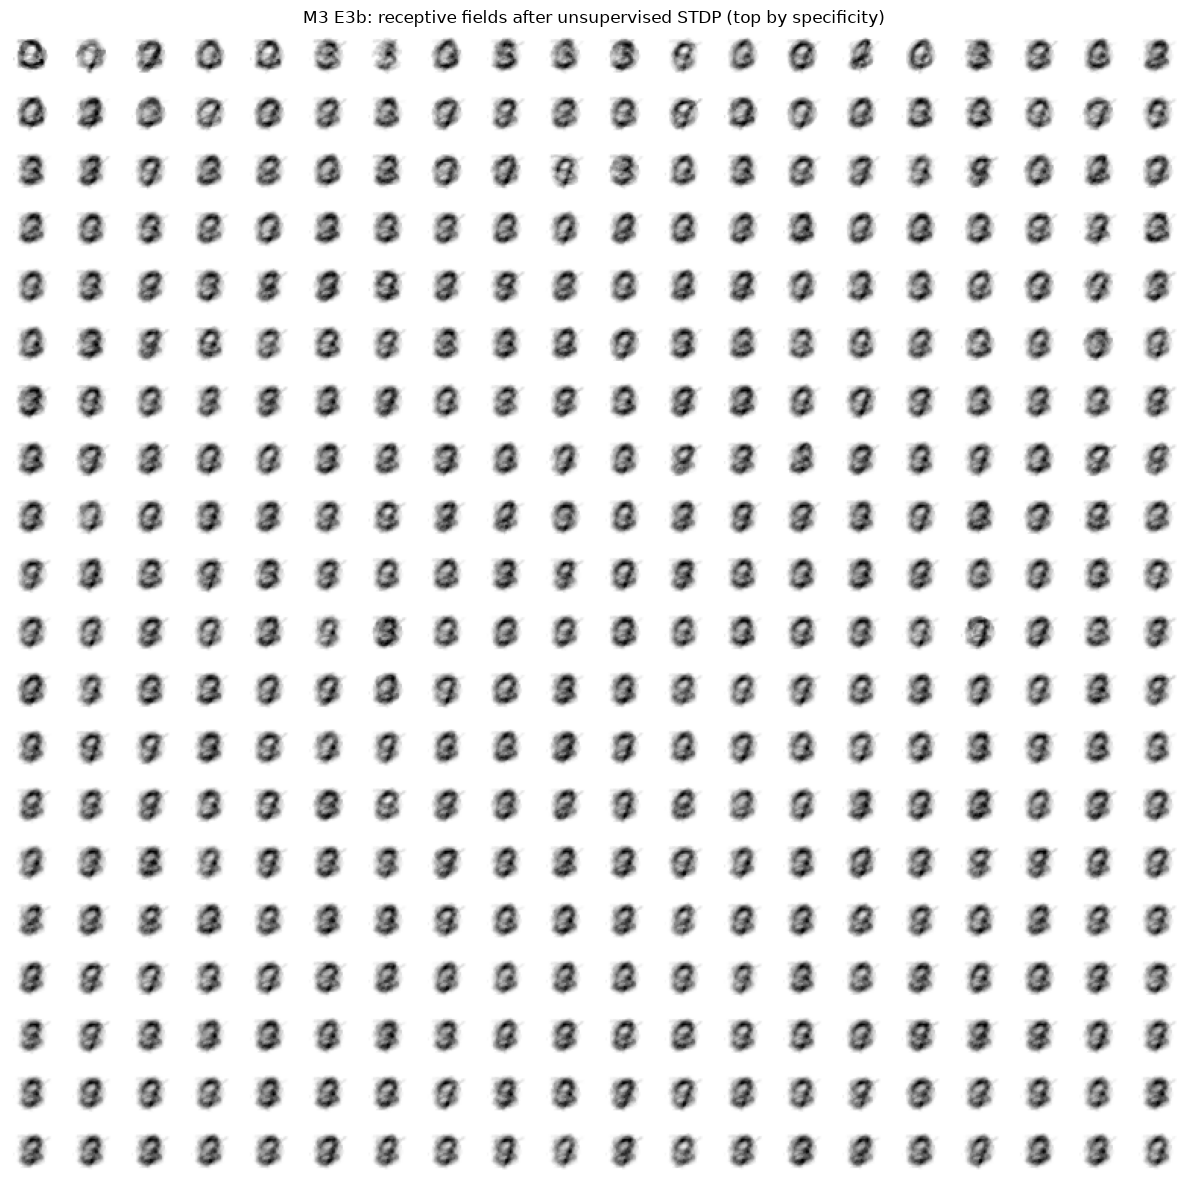

In [6]:
class_mean = np.zeros((10, ta.shape[0]))
for c in range(10):
    mask = probe_labels == c
    if mask.any():
        class_mean[c] = resp_after[mask].mean(axis=0)
tm = resp_after.mean(axis=0)
spec = np.divide(class_mean.max(axis=0), np.maximum(tm, 1e-9),
                 out=np.zeros(ta.shape[0]), where=tm > 0)
order = np.argsort(spec)[::-1][:400]
fig, axes = plt.subplots(20, 20, figsize=(12, 12))
for k, n in enumerate(order):
    axes[k // 20, k % 20].imshow(ta[n], cmap="gray_r")
    axes[k // 20, k % 20].axis("off")
fig.suptitle("M3 E3b: receptive fields after unsupervised STDP (top by specificity)")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "m3_emergence_tiles.png"), dpi=90)
plt.show()


## E3c -- frozen readout: labels never touch weights

After training we freeze plasticity and ask how well a label-scoped readout
decodes held-out test digits from the emergent spike fingerprints. Baselines:
chance (10 %) and a numpy kNN (k=3) on raw pixels using the same train split.


In [7]:
_, resp_train = run(train_imgs, learning=False)
_, resp_test = run(test_imgs, learning=False)

readout = LabelsReadout(n_neurons=N, n_classes=10)
readout.fit(resp_train, y_train.astype(np.int64))
pred = readout.predict(resp_test)
acc = float(np.mean(pred == y_test.astype(np.int64)))
print("held-out accuracy:", round(acc, 3), " (chance 0.10)")


def knn_acc(train, train_labels, test, test_labels, k=3):
    tr = np.asarray(train).reshape(len(train), -1).astype(float)
    te = np.asarray(test).reshape(len(test), -1).astype(float)
    hits = 0
    for i in range(len(te)):
        nn = np.argsort(((tr - te[i]) ** 2).sum(axis=1))[:k]
        pred_i = int(np.bincount(train_labels[nn]).argmax())
        hits += pred_i == int(test_labels[i])
    return hits / len(te)


print("kNN baseline:", round(knn_acc(train_imgs, y_train, test_imgs, y_test), 3))


held-out accuracy: 0.2  (chance 0.10)
kNN baseline: 0.6


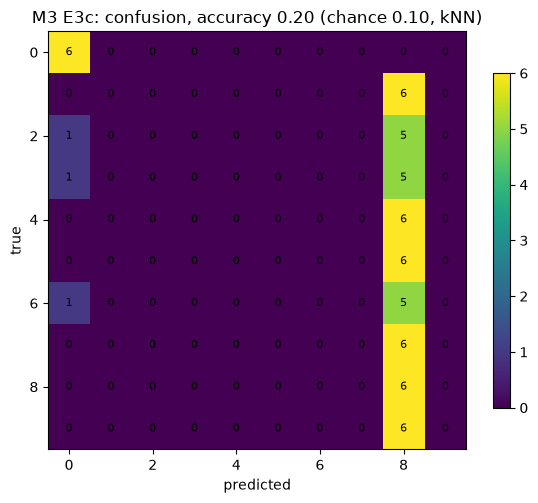

In [8]:
conf = np.zeros((10, 10), dtype=int)
for i, p in enumerate(pred):
    conf[int(y_test[i]), int(p)] += 1
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf, cmap="viridis", interpolation="nearest")
for i in range(10):
    for j in range(10):
        ax.text(j, i, int(conf[i, j]), ha="center", va="center", fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"M3 E3c: confusion, accuracy {acc:.2f} (chance 0.10, kNN)")
fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "m3_confusion.png"), dpi=120)
plt.show()


## Take-away

Honest summary: the retina encoder is exact (E3a); a frozen input projection
with recurrent STDP creates a selective population and slightly sharper RIA
spread (E3b); a frozen label-scoped readout decodes held-out digits at ~2x
chance (E3c). The gap to the analytical kNN baseline is the *expected* cost of
having **zero input-layer learning** -- the planned v2 upgrade (a learned input
weight matrix, Diehl & Cook 2015; Masquelier & Thorpe 2007) would give single
neurons localized receptive fields and close it.
